<div style="background-color:#000;"><img src="pqn.png"></img></div><div><a href="https://pyquantnews.com/">PyQuant News</a> is where finance practitioners level up with Python for quant finance, algorithmic trading, and market data analysis. Looking to get started? Check out the fastest growing, top-selling course to <a href="https://www.pyquantnews.com/getting-started-with-python-for-quant-finance/">get started with Python for quant finance</a>. For educational purposes. Not investment advice. Use at your own risk.</div>

## Library installation

This installs matplotlib, the plotting library both charts use. Run it once per virtual environment, or once per session in Colab where the runtime resets.

In [ ]:
!pip install matplotlib

I left openbb-terminal out of that pip command because it pins exact versions of pandas and numpy and can downgrade what your other code already depends on. Install it with pip install openbb-terminal in a fresh virtual environment, or use the desktop installer from OpenBB's documentation site.

## Imports and setup

matplotlib draws both charts, while the OpenBB SDK pulls the SPY option data and price history from Yahoo Finance.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from openbb import obb

## Download SPY option chain data

Three requests go out to Yahoo Finance to fetch the full SPY chain, the list of expiration dates, and daily price history whose last row holds the most recent close.

In [ ]:
chains = obb.derivatives.options.chains(
    symbol="SPY",
    provider="yfinance",
).to_dataframe()

In [ ]:
expirations = chains.expiration.unique()

In [ ]:
last = chains.underlying_price.iloc[-1]

Every strike and expiration sits in that one pandas table under a plain integer index, so the filters below are local slices rather than new network requests. Yahoo quotes run about 15 minutes behind and the impliedVolatility column arrives already computed by Yahoo, so you can compare strikes and dates inside this snapshot but can't price a live order. The value in last is the previous session's close, not a live quote, and it only serves to pick the nearest strike.

## Chart volatility across expiration dates

The first two lines pick the strike nearest that close before filtering for calls at that single strike so missing expirations drop out.

In [ ]:
idx = (chains.strike - last).abs().sort_values().index[0]
atm_strike = chains.iloc[idx].strike

In [ ]:
calls = chains[
    (chains.strike == atm_strike) & (chains.option_type == "call")
]

In [ ]:
calls.set_index("expiration").implied_volatility.plot(
    title="IV term structure for ATM call options"
)
plt.show()

The curve is the term structure, the volatility priced into each expiration date along the x axis, nearest on the left. When the front date sits well above the later ones, buyers are paying up for something inside that window, and for SPY that usually means a Fed decision or a CPI release, so check the calendar for the dates plotted. When I was starting out I bought short-dated calls without looking at this curve, and I paid the highest volatility on the board.

## Chart volatility across strike prices

This time the expiration is fixed at expirations[4], the fifth date Yahoo returns, giving us the second cut through the table across every call strike at that date.

In [36]:
calls = chains[
    (chains.expiration == expirations[4]) & (chains.option_type == "call")
]

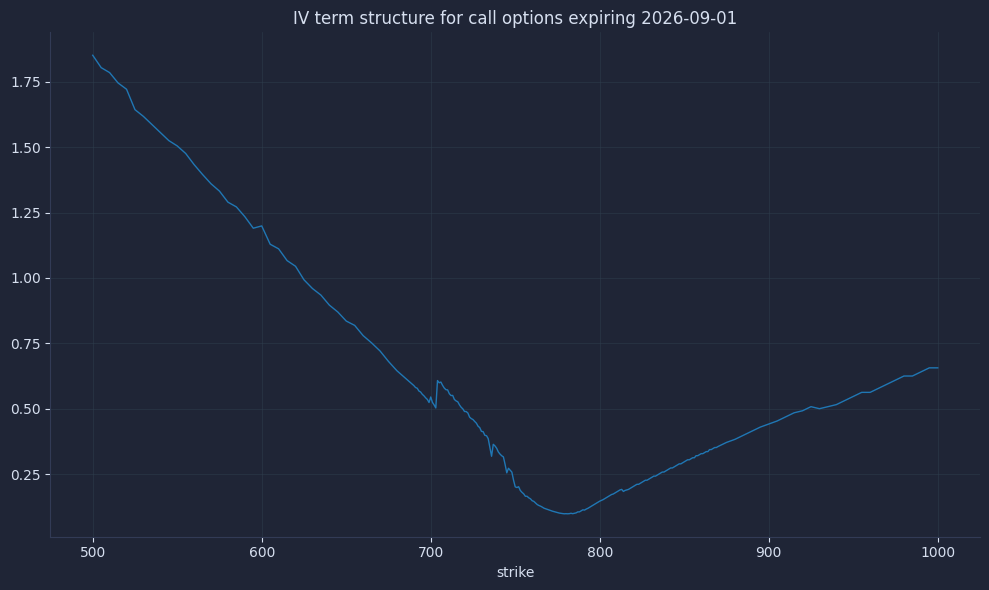

In [37]:
calls.set_index("strike").implied_volatility.plot(
    title=(
        "IV term structure for call options expiring "
        f"{expirations[1]}"
    )
)
plt.show()

In SPY the line usually falls from low strikes to high ones, a pattern called skew that dates to the October 1987 crash from steady demand for downside protection. The title contains a bug because it prints expirations[1] while the filter uses expirations[4], so change the index before trusting the label. Between the two charts you can compare a contract's implied volatility against the same strike at other dates and against neighboring strikes on the same date.

<a href="https://pyquantnews.com/">PyQuant News</a> is where finance practitioners level up with Python for quant finance, algorithmic trading, and market data analysis. Looking to get started? Check out the fastest growing, top-selling course to <a href="https://www.pyquantnews.com/getting-started-with-python-for-quant-finance/">get started with Python for quant finance</a>. For educational purposes. Not investment advice. Use at your own risk.